# 3.6 — Render rollouts in Blender

`scripts/render_blender.py` turns a MyoSuite CPU rollout into an anatomical, studio-lit render in
[Blender](https://www.blender.org/). It exports the episode to animated USD (bones, task objects and
**volumetric muscles**), then builds a Cycles scene: ivory bones, glossy muscles that turn from rose
to deep red as they activate, and a seamless studio backdrop. The muscle look follows the volumetric
visualiser of [MuSkeMo](https://github.com/PashavanBijlert/MuSkeMo).

| | | |
|---|---|---|
| ![leg](../docs/source/images/blender/leg.jpg) | ![hand](../docs/source/images/blender/hand.jpg) | ![elbow](../docs/source/images/blender/elbow.jpg) |
| `myoLegWalk-v0` | `myoHandReorient8-v0` | `myoElbowPose1D6MRandom-v0` |

This notebook covers:
1. exporting a rollout (no Blender needed),
2. what the export contains and how the muscle volumes are computed,
3. rendering a preview frame and a short video,
4. the main options, and rendering a trained policy.

## Requirements

- The USD exporter dependencies: `pip install usd-core` (or `pip install "mujoco[usd]"`).
- Blender 4.5 LTS or newer for steps 3-4 ([download](https://www.blender.org/download/)). Point the
  `BLENDER` environment variable to its executable, or put `blender` on your `PATH`.
  Without Blender, steps 1-2 still run and step 3 shows the reference images above.

In [2]:
import json
import os
import shutil
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Video, display
from PIL import Image as PILImage

from myosuite.viz import muscle_tubes
from myosuite.viz.blender_render import RenderConfig, render_rollout

BLENDER = os.environ.get("BLENDER") or shutil.which("blender")
OUT = Path(tempfile.mkdtemp(prefix="myosuite-blender-"))
print("blender:", Path(BLENDER).name if BLENDER else "not found (steps 3-4 are skipped)")
print("output: ", OUT)


def show(path: Path, width: int) -> None:
    """Display a render as a compact JPEG."""
    jpeg = path.with_suffix(".jpg")
    PILImage.open(path).convert("RGB").save(jpeg, quality=85)
    display(Image(filename=jpeg, width=width))

blender: blender
output:  /tmp/myosuite-blender-810pw7ku


## 1. Export a rollout

`RenderConfig` holds the render settings (the same as the options of `scripts/render_blender.py`).
`render_rollout(config, export_only=True)` runs one CPU episode and writes the USD animation without
starting Blender. Without a `checkpoint` the env is driven by random actions (step 4 shows a trained
policy). Recording stops after `seconds` or when the episode terminates.

In [3]:
elbow = OUT / "elbow"
render_rollout(RenderConfig(env="myoElbowPose1D6MRandom-v0", output=elbow, seconds=1), export_only=True)
print(sorted(p.name for p in elbow.iterdir()))

Exported 51 samples, 1.000s to /tmp/myosuite-blender-810pw7ku/elbow/usd/frames/frame_51.usdc
['muscles.npz', 'reference.npz', 'render.json', 'usd']


## 2. What the export contains

- `usd/frames/frame_N.usdc`: the animated scene (metres, simulation timing), including one tube mesh per muscle.
- `render.json`: render settings and the object lists the Blender stage uses (bones, muscles, scenery).
- `muscles.npz`: muscle activation per control step, which drives the muscle colour.
- `reference.npz`: recorded `qpos` and geom poses, to check the render against the simulation.

51 samples at dt = 0.020 s, 6 muscles, 68 bone meshes


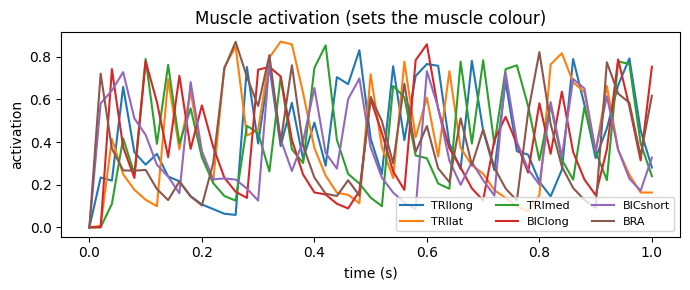

In [4]:
meta = json.loads((elbow / "render.json").read_text())
activation = np.load(elbow / "muscles.npz")["activation"]
t = np.arange(len(activation)) * meta["dt"]
print(f"{meta['samples']} samples at dt = {meta['dt']:.3f} s, {len(meta['muscle_objects'])} muscles, {len(meta['bone_objects'])} bone meshes")

fig, ax = plt.subplots(figsize=(7, 3))
for name, a in zip(meta["muscle_objects"], activation.T):
    ax.plot(t, a, label=name.removeprefix("Muscle_"))
ax.set(xlabel="time (s)", ylabel="activation", title="Muscle activation (sets the muscle colour)")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()

### Volumetric muscles

Each muscle is a tube along its MuJoCo tendon path, with a fusiform belly and thin tendons
(0.2 of the belly radius). The shape is set so that the muscles look anatomical:

- **Thickness.** The peak cross-section is `F_max / 1.6 MPa`. This stress was fitted to measured
  cross-sections of forearm and leg muscles. The MuSkeMo volume `F_max / 300 kPa * L0` assumes
  anatomical forces and would make MyoSuite's forearm muscles 5-15 times too large.
- **Belly length.** The belly is as long as the optimal fibre length `L0`, or longer when its
  cross-section needs it (short-fibred, pennate leg muscles). It covers 40-80% of the path and sits
  towards the origin, so finger flexors and extensors end in the forearm and long tendons run to the
  fingers.
- **Volume.** The volume is fixed for the episode, so a muscle that shortens gets thicker.

The table compares the forearm volumes with measured adult volumes (approximate means from
Holzbaur et al. 2007; FDS, FDP and EDC split evenly over their compartments).

muscle   radius mm belly cm volume cm3 measured
FCR_r          9.0     12.5       19.9       17
FCU_r          9.8     13.1       24.4       26
ECRL_r         8.2     13.1       17.2       19
ECU_r          6.2     11.8        8.9       17
PT_r          10.5      7.7       16.1       19
FDS3_r         7.2     20.7       19.8       14
FDP3_r         6.5     20.9       16.4       15
EDC3_r         4.3     19.0        6.9        5
FPL_r          6.3     18.9       13.8       12


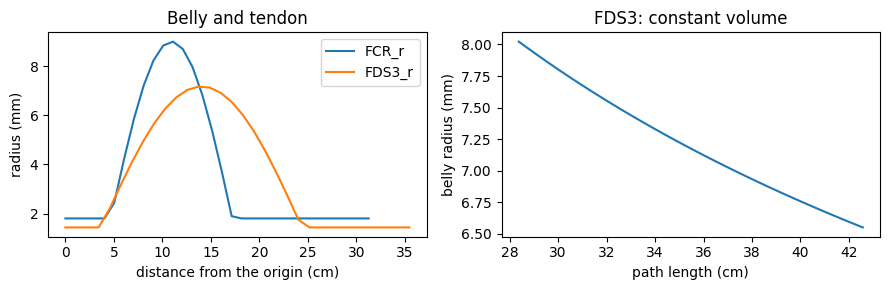

In [5]:
from myosuite import make_env

env = make_env("myoHandPoseRandom-v0")
env.reset(seed=0)
model, data = env.unwrapped.model, env.unwrapped.data
muscles = muscle_tubes.muscle_actuators(model)
names = [model.actuator(a).name for a in muscles]
lengths = data.ten_length[model.actuator_trnid[muscles, 0]]
peak, fraction = muscle_tubes.muscle_shape(model, lengths)
profiles = muscle_tubes.radius_profile(fraction)
volumes = muscle_tubes.belly_volume(peak, lengths, profiles)
env.close()

measured = {"FCR_r": 17, "FCU_r": 26, "ECRL_r": 19, "ECU_r": 17, "PT_r": 19, "FDS3_r": 14, "FDP3_r": 15, "EDC3_r": 5, "FPL_r": 12}
print(f"{'muscle':8s} {'radius mm':>9s} {'belly cm':>8s} {'volume cm3':>10s} {'measured':>8s}")
for name, ref in measured.items():
    i = names.index(name)
    print(f"{name:8s} {peak[i] * 1000:9.1f} {fraction[i] * lengths[i] * 100:8.1f} {volumes[i] * 1e6:10.1f} {ref:8d}")

fig, (left, right) = plt.subplots(1, 2, figsize=(9, 3))
for name in ("FCR_r", "FDS3_r"):
    i = names.index(name)
    left.plot(np.linspace(0, lengths[i] * 100, profiles.shape[-1]), profiles[i] * peak[i] * 1000, label=name)
left.set(xlabel="distance from the origin (cm)", ylabel="radius (mm)", title="Belly and tendon")
left.legend()
i = names.index("FDS3_r")
shortening = np.linspace(0.8, 1.2, 50) * lengths[i]
right.plot(shortening * 100, muscle_tubes.belly_radius(volumes[i], shortening, profiles[i]) * 1000)
right.set(xlabel="path length (cm)", ylabel="belly radius (mm)", title="FDS3: constant volume")
plt.tight_layout()

## 3. Render a preview frame

`--preview` renders the first frame to `preview.png` and saves the editable `scene.blend`.
`--samples` sets the Cycles quality (64 by default; 16-32 is enough for a draft).

Exported 21 samples, 0.200s to /tmp/myosuite-blender-810pw7ku/leg/usd/frames/frame_21.usdc


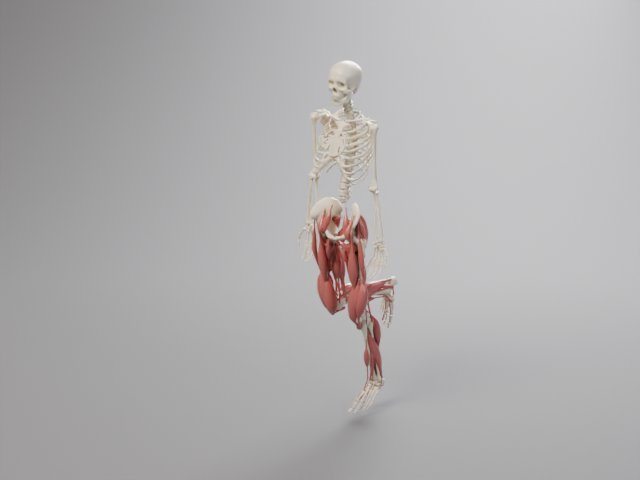

In [6]:
if BLENDER:
    leg = OUT / "leg"
    render_rollout(RenderConfig(env="myoLegWalk-v0", output=leg, seconds=0.2, preview=True,
                                resolution=(640, 480), samples=32, blender=BLENDER),
                   blender_log=OUT / "blender.log")
    show(leg / "preview.png", 640)
else:
    display(Image(filename="../docs/source/images/blender/leg.jpg", width=640))

### A short video

Without `--preview` every frame is rendered and assembled into `video.mp4` at `--fps`.
Rendering is the slow part (Cycles on the CPU), so keep drafts small.

In [7]:
if BLENDER:
    clip = OUT / "elbow_video"
    render_rollout(RenderConfig(env="myoElbowPose1D6MRandom-v0", output=clip, seconds=0.6, fps=15,
                                resolution=(320, 240), samples=16, blender=BLENDER),
                   blender_log=OUT / "blender.log")
    display(Video(str(clip / "video.mp4"), embed=True, width=480))

Exported 31 samples, 0.600s to /tmp/myosuite-blender-810pw7ku/elbow_video/usd/frames/frame_31.usdc


Multiple -pix_fmt options specified for stream 0, only the last option '-pix_fmt yuv420p' will be used.


## 4. Options

| `RenderConfig` field (CLI option) | Effect |
|---|---|
| `muscles="volumetric"` / `"paths"` (`--muscles`) | volumetric muscle bellies (default), or MuJoCo's thin tendon paths |
| `muscle_scale=0.7` (`--muscle-scale`) | multiplies all muscle radii (thinner muscles show more bone) |
| `muscle_color="activation"` / `"uniform"` (`--muscle-color`) | tint each muscle by its activation (on `paths` with MuJoCo's dark-to-red viewer colours), or one anatomical red for still renders |
| `scene="studio"` / `"mujoco"` (`--scene`) | studio backdrop (default), or keep the task's own floor, e.g. a soccer pitch or the ChaseTag arena |
| `samples`, `resolution`, `fps` | render quality, size and video rate |
| `seed`, `seconds`, `checkpoint` | episode seed, clip length and policy |
| `skin="fullbody"` or a `.skn` path (`--skin`) | MuJoCo body skin over the anatomy; `skin_style` `"translucent"` / `"opaque"`, `skin_alpha`, `skin_inflate` |

The ChaseTag image below uses `--scene mujoco`, so the arena floor and fences stay visible.

![chasetag](../docs/source/images/blender/chasetag.jpg)

Exported 11 samples, 0.200s to /tmp/myosuite-blender-810pw7ku/elbow_paths/usd/frames/frame_11.usdc


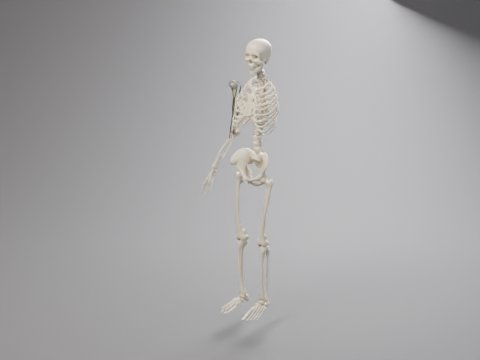

In [8]:
if BLENDER:
    thin = OUT / "elbow_paths"
    render_rollout(RenderConfig(env="myoElbowPose1D6MRandom-v0", output=thin, seconds=0.2, preview=True,
                                muscles="paths", resolution=(480, 360), samples=16, blender=BLENDER),
                   blender_log=OUT / "blender.log")
    show(thin / "preview.png", 480)

### Body skin

`skin` adds a MuJoCo `.skn` skin, posed from the body poses of every frame (`myosuite.viz.skin`). 
`"fullbody"` is the bundled skin for `myoMimicFullbody-v0`; any other `.skn` binds to a model by body name. 
The translucent style shows muscles and bones through the skin; `"opaque"` hides them.

Exported 11 samples, 0.100s to /tmp/myosuite-blender-810pw7ku/fullbody_skin/usd/frames/frame_11.usdc


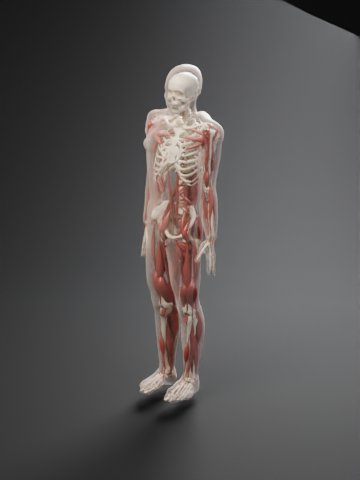

In [9]:
if BLENDER:
    skin = OUT / "fullbody_skin"
    render_rollout(RenderConfig(env="myoMimicFullbody-v0", output=skin, seconds=0.1, preview=True,
                                muscle_color="uniform", skin="fullbody", skin_style="translucent",
                                resolution=(360, 480), samples=32, blender=BLENDER),
                   blender_log=OUT / "blender.log")
    show(skin / "preview.png", 360)

### Render a trained policy

Pass a checkpoint instead of random actions: an SB3 `.zip`, an RSL-RL `.pt`, or a run directory (its newest
`model_*.pt` is used). A checkpoint that does not fit the env raises an error instead of falling back to random
actions.

The cell below renders the published `myoLegWalk-v0` baseline. `download_baseline_checkpoint` fetches it from
[myohub/myosuite-3-baselines](https://huggingface.co/myohub/myosuite-3-baselines) on Hugging Face (the
checkpoints tagged for your MyoSuite release, cached after the first download) and returns its folder.
Tutorials 1.2 and 2.2 show the other baselines and how to train your own.

From the command line, simply leave out `--checkpoint`: the script then uses the newest local training run of
the env or, if there is none, the published baseline above, and prints which checkpoint it picked.

```bash
python scripts/render_blender.py --env myoLegWalk-v0 \
    --seconds 1.5 --fps 15 --resolution 320 240 --samples 16 --output renders/walk --blender /path/to/blender
```


In [10]:
from myosuite.core.hf_io import download_baseline_checkpoint

checkpoint = download_baseline_checkpoint("myoLegWalk-v0")  # the published baseline, from Hugging Face
print("checkpoint:", sorted(p.name for p in checkpoint.iterdir()))

walk = OUT / "walk"
config = RenderConfig(env="myoLegWalk-v0", checkpoint=checkpoint, output=walk, seconds=1.5, fps=15,
                      resolution=(320, 240), samples=16, blender=BLENDER or "blender")
if BLENDER:
    render_rollout(config, blender_log=OUT / "blender.log")
    display(Video(str(walk / "video.mp4"), embed=True, width=480))
else:
    render_rollout(config, export_only=True)  # the trained gait as USD, without Blender


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Using baselines of myohub/myosuite-3-baselines at revision 'v3.0' (tag 'v3.0.0' not found)
checkpoint: ['manifest.json', 'model_3000.pt']
mjlab policy: /home/mifs/fjf33/.cache/huggingface/hub/models--myohub--myosuite-3-baselines/snapshots/4b3fd745053ce89f20cf642fbf8e359fd1a55a98/checkpoints/myoLegWalk-v0/model_3000.pt
Exported 151 samples, 1.500s to /tmp/myosuite-blender-810pw7ku/walk/usd/frames/frame_151.usdc


Multiple -pix_fmt options specified for stream 0, only the last option '-pix_fmt yuv420p' will be used.


Keep each output folder together: `scene.blend` refers to the USD cache by a relative path. Open it in
Blender to change the camera, lights or materials and render again. See `docs/source/blender_rendering.rst`
for the full reference.
